In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# 设置中文显示（可选）
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

In [ ]:
# 读取指定范围的数据（A33:D134，跳过前32行，读取101行）
df = pd.read_excel("../data/stock_price.xlsx", sheet_name="Sheet1", 
                   usecols="A:D", skiprows=32, nrows=101, 
                   header=None, names=['Var1', 'Var2', 'SH', 'SH_1'])

# 只保留需要的列并转换为 numpy 数组
stock_price = df[['SH', 'SH_1']].values

print(f"数据维度: {stock_price.shape}")
print(f"前5行数据:\n{stock_price[:5]}")

数据维度: (101, 2)
前5行数据:
[[4.41 4.43]
 [4.4  4.4 ]
 [4.39 4.41]
 [4.39 4.42]
 [4.44 4.48]]


In [ ]:
# MATLAB: S = mean(stock_price, 2) - 沿行求均值（即开盘价和收盘价的均值）
S = np.mean(stock_price, axis=1)
print(f"价格均值 S 的长度: {len(S)}")

价格均值 S 的长度: 101


In [ ]:
# MATLAB: R = diff(log(S)); R = [0; R];
log_S = np.log(S)
R = np.diff(log_S)  # 计算差分，长度比原数组少1
R = np.insert(R, 0, 0)  # 在开头插入0，使长度与S一致

R_ave = np.mean(R)
print(f"对数收益率均值 R_ave: {R_ave:.6f}")

对数收益率均值 R_ave: 0.000909


In [ ]:
W = 10  # 时间窗口
n_windows = len(R) - W + 1

R_ave_w = np.zeros(n_windows)
for i in range(n_windows):
    R_ave_w[i] = np.mean(R[i:i+W])

print(f"窗口数量: {n_windows}")
print(f"窗口均值前5个: {R_ave_w[:5]}")

窗口数量: 92
窗口均值前5个: [0.00624861 0.00624861 0.0065958  0.00723207 0.00879568]


In [ ]:
d = np.zeros(n_windows)
for i in range(n_windows):
    d[i] = np.std(R[i:i+W], ddof=1)  # ddof=1 对应 MATLAB 的无偏估计（样本标准差）

print(f"波动率前5个: {d[:5]}")

波动率前5个: [0.00943566 0.00943566 0.0090508  0.0087544  0.00893898]


In [ ]:
# O: 波动率的长期均值
O = np.mean(d)
# d_v: 波动率的波动率（标准差）
d_v = np.std(d, ddof=1)

print(f"O (长期均值): {O:.6f}")
print(f"d_v (波动率的波动率): {d_v:.6f}")

# K (kappa): 波动率回归速度
# MATLAB 逻辑: K = -cov(d(i-1)-O, d(i)-d(i-1)) / var(d(i-1)-O)
d_prev = d[:-1]  # d(i-1)
d_curr = d[1:]   # d(i)

# 计算协方差和方差
delta_d = np.diff(d)  # d(i) - d(i-1)
centered_d_prev = d_prev - O

# 使用样本协方差（除以 n-1）与 MATLAB 保持一致
n = len(delta_d)
cov_val = np.sum(centered_d_prev * delta_d) / (n - 1)
var_val = np.sum(centered_d_prev ** 2) / (n - 1)

K = -cov_val / var_val
print(f"K (回归速度): {K:.6f}")

O (长期均值): 0.007919
d_v (波动率的波动率): 0.001931
K (回归速度): 0.097802


In [ ]:
# d 的长度是 n_windows = len(R) - W + 1 = 92
# 因此取 R 的前92个，与 d 对齐

# 方法1：直接取相同长度（推荐）
length_for_corr = len(d)  # 92
A = R[:length_for_corr]
d_subset = d  # d 已经是92个元素

# 方法2：如果你想用全部可用数据，使用 min
# length_for_corr = min(len(R), len(d))
# A = R[:length_for_corr]
# d_subset = d[:length_for_corr]

p, _ = pearsonr(A, d_subset)
print(f"用于计算相关的数据长度: {length_for_corr}")
print(f"相关系数 p: {p:.6f}")

用于计算相关的数据长度: 92
相关系数 p: 0.177992


In [ ]:
# 参数设置
v0 = O  # 初始波动率
S0 = 4.87  # 初始股票价格
r = 0.05  # 无风险利率
T = 1  # 到期时间（年）
M = 100  # 时间步数
dt = T / M  # 时间步长
N_paths = 20  # 路径数量

# 初始化路径数组（注意：Python索引从0开始）
vPaths = np.zeros((M + 1, N_paths))
SPaths = np.zeros((M + 1, N_paths))

vPaths[0, :] = v0
SPaths[0, :] = S0

# 生成随机布朗运动增量
dW_t = np.sqrt(dt) * np.random.randn(M + 1, N_paths)
dZ_t = np.sqrt(dt) * np.random.randn(M + 1, N_paths)

# 模拟 Heston 模型路径
for t in range(1, M + 1):
    for i in range(N_paths):
        # 确保波动率不会变成负数
        dv = K * (O - vPaths[t - 1, i]) * dt + \
             d_v * np.sqrt(vPaths[t - 1, i]) * dW_t[t, i]
        
        vPaths[t, i] = max(vPaths[t - 1, i] + dv, 0)
        
        # 股票价格更新（注意相关系数 p 的处理）
        dS = (r - vPaths[t, i]/2) * dt + \
             np.sqrt(vPaths[t, i]) * (p * dW_t[t, i] + np.sqrt(1 - p**2) * dZ_t[t, i])
        SPaths[t, i] = SPaths[t - 1, i] * np.exp(dS)

# 提取股票价格路径（去掉初始时刻）
S_t_paths = SPaths[1:, :]

# 生成时间步
timeSteps = np.linspace(0, T, M + 1)[1:]  # 去掉初始的0时间点

print(f"模拟完成。路径形状: {S_t_paths.shape}")

模拟完成。路径形状: (100, 20)


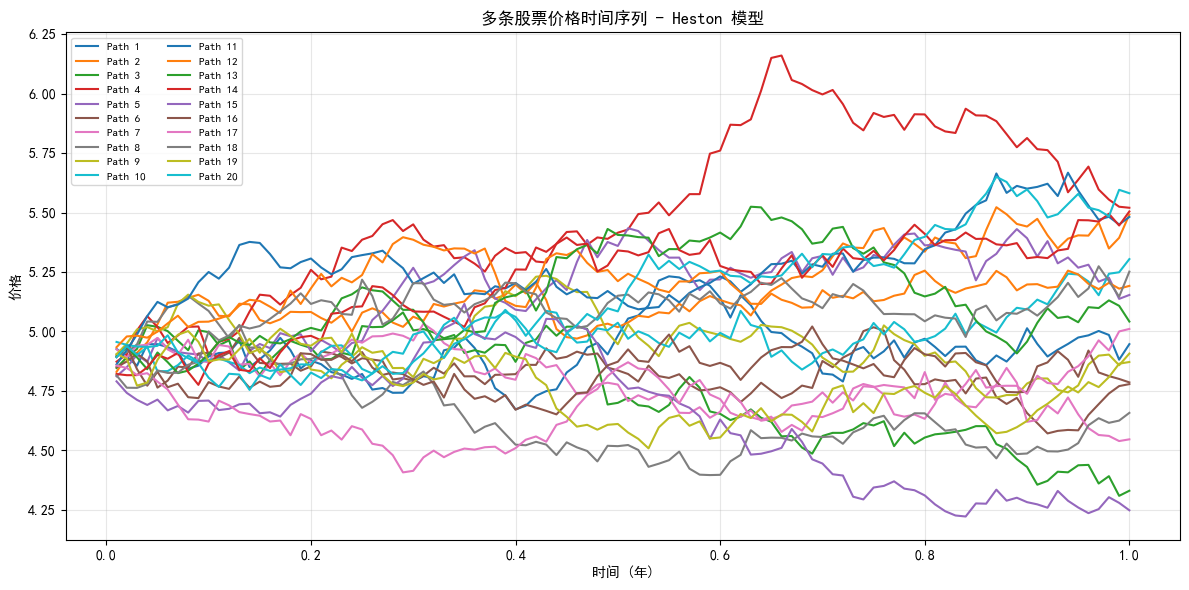

In [ ]:
plt.figure(figsize=(12, 6))

for i in range(N_paths):
    plt.plot(timeSteps, S_t_paths[:, i], linewidth=1.5, label=f'Path {i+1}')

plt.title('多条股票价格时间序列 - Heston 模型')
plt.xlabel('时间 (年)')
plt.ylabel('价格')
plt.grid(True, alpha=0.3)

# 如果路径太多，可以只显示图例的一部分或省略
if N_paths <= 10:
    plt.legend(loc='best')
else:
    plt.legend([f'Path {i+1}' for i in range(N_paths)], 
               loc='best', ncol=2, fontsize=8)

plt.tight_layout()
plt.show()